# Forecasting International Student Mobility

**Group 26:** Adriano Machado, Francisco da Ana, João Lopes, Tiago Teixeira

ESN Porto is a non-profit that supports international exchange students in Porto. Students who buy a membership card get discounts at local businesses, invitations to social events, and access to cultural activities.

We analyzed five years of membership data to identify trends and forecast **weekly** sign-ups. Better predictions mean ESN Porto can staff appropriately, having enough volunteers ready when students need help most, and schedule events when demand is highest.


In [6]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path
from datetime import datetime, timedelta

# Models
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import ElasticNet

# Validation & Selection
from sklearn.model_selection import TimeSeriesSplit
from sklearn.feature_selection import RFECV
import optuna
import warnings
from matplotlib.gridspec import GridSpec

In [7]:
DATA_DIR = Path('data')
FIGURES_DIR = Path('figures')
RESULTS_DIR = Path('results')
FIGURES_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)

# Configuration: Set to True to run hyperparameter tuning, False to load from saved results
RUN_HYPERPARAMETER_TUNING = True

In [8]:
data_dir = Path('data')

with open(data_dir / 'eventupp_students_private.json', 'r') as f:
    data = json.load(f)

df = pd.DataFrame(data)

print(f"Loaded data from: {data_dir / 'eventupp_students_private.json'}")
print(f"Total students: {len(df):,}")
print(f"Academic years: {sorted(df['academic_year'].unique())}")

Loaded data from: data/eventupp_students_private.json
Total students: 14,168
Academic years: ['2021_2022', '2022_2023', '2023_2024', '2024_2025', '2025_2026']


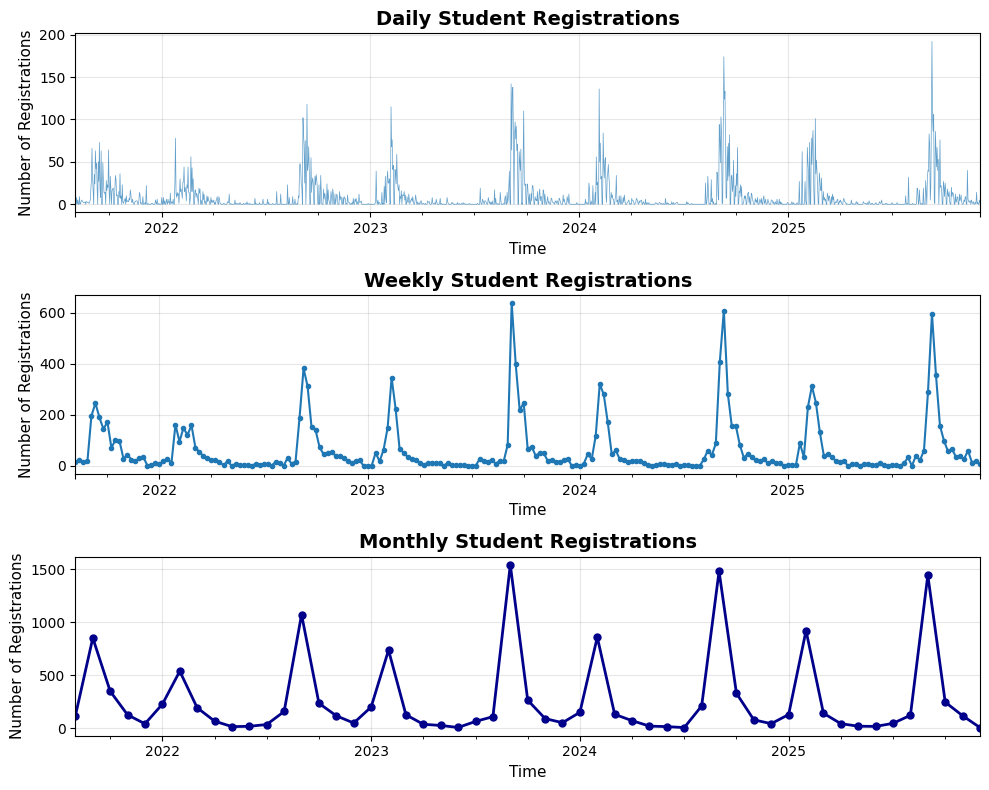

In [16]:

daily_counts = df.groupby(df['registerDate_dt'].dt.date).size()
daily_ts = pd.Series(daily_counts.values, index=pd.to_datetime(daily_counts.index))
daily_ts = daily_ts.asfreq('D', fill_value=0)  

weekly_ts = daily_ts.resample('W').sum()

monthly_ts = daily_ts.resample('ME').sum()

fig = plt.figure(figsize=(10, 8))

# Plot 1: Daily registrations
ax1 = plt.subplot(3, 1, 1)
daily_ts.plot(ax=ax1, linewidth=0.5, alpha=0.7)
ax1.set_title('Daily Student Registrations', fontsize=14, fontweight='bold')
ax1.set_xlabel('Time', fontsize=11)
ax1.set_ylabel('Number of Registrations', fontsize=11)
ax1.grid(True, alpha=0.3)

# Plot 2: Weekly registrations
ax2 = plt.subplot(3, 1, 2)
weekly_ts.plot(ax=ax2, linewidth=1.5, marker='o', markersize=3)
ax2.set_title('Weekly Student Registrations', fontsize=14, fontweight='bold')
ax2.set_xlabel('Time', fontsize=11)
ax2.set_ylabel('Number of Registrations', fontsize=11)
ax2.grid(True, alpha=0.3)

# Plot 3: Monthly registrations
ax3 = plt.subplot(3, 1, 3)
monthly_ts.plot(ax=ax3, linewidth=2, marker='o', markersize=5, color='darkblue')
ax3.set_title('Monthly Student Registrations', fontsize=14, fontweight='bold')
ax3.set_xlabel('Time', fontsize=11)
ax3.set_ylabel('Number of Registrations', fontsize=11)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
plt.close()
